In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data loaded successfully! Training shape:", X_train.shape)

Data loaded successfully! Training shape: (455, 30)


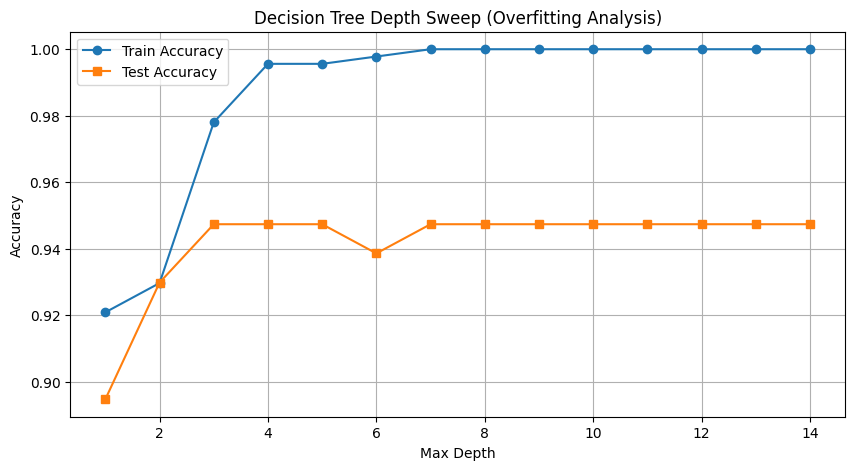

In [3]:
max_depths = range(1, 15)
train_accuracies = []
test_accuracies = []

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Plotting Depth Sweep
plt.figure(figsize=(10, 5))
plt.plot(max_depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(max_depths, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth Sweep (Overfitting Analysis)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
criteria = ['gini', 'entropy']
for criterion in criteria:
    clf = DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Criterion: {criterion.capitalize()} | Test Accuracy: {acc:.4f}")

Criterion: Gini | Test Accuracy: 0.9474
Criterion: Entropy | Test Accuracy: 0.9561


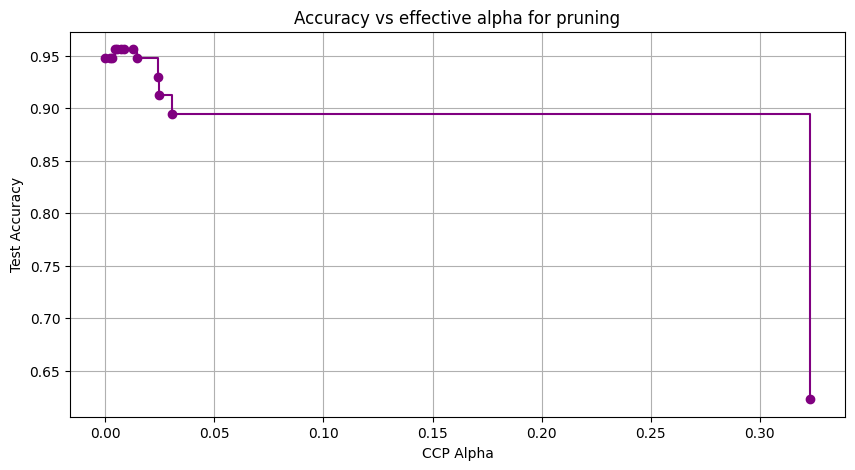

In [5]:
# Get effective alphas for pruning
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Train trees across different ccp_alphas
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Evaluate test accuracy for each pruned tree
test_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, test_scores, marker='o', drawstyle="steps-post", color='purple')
plt.xlabel('CCP Alpha')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs effective alpha for pruning')
plt.grid(True)
plt.show()